# 02 · KV cache management with Mooncake

The KV cache holds the attention state of every token a request has seen. It lives in GPU memory, and on this RTX 5090 there's room for **209,472 tokens**. When prompts don't fit, vLLM evicts old cache blocks, and anything evicted has to be **recomputed** (prefilled again) if the same prompt comes back.

[Mooncake](https://github.com/kvcache-ai/Mooncake) adds a second tier: a KV store in CPU memory. vLLM's `MooncakeStoreConnector` writes KV blocks there as they're computed, and on a GPU cache miss it can **load** them back instead of recomputing.

This notebook measures what that buys on one GPU, and what it costs. All numbers are read from `results/02_kv_cache_mooncake/`.

## How much KV cache is a token?

For Qwen2.5 7B: 28 layers × 4 KV heads × 128 dims × 2 (key and value) × 2 bytes (BF16) = **57,344 bytes per token** (56 KiB).

That matches vLLM's own numbers: 11.19 GiB of KV cache memory ÷ 209,472 tokens = 57,350 bytes per token.

| Tier | Size | Tokens of KV |
|---|---|---|
| GPU (vLLM's KV cache) | 11.19 GiB | 209,472 |
| Mooncake store (CPU memory, `vllm/mooncake/mooncake_config.json`) | 32 GB | ~558,000 |

## The experiment

`scripts/kv_cache_experiment.py` sends **48 distinct documents of ~5,950 tokens** (~286k tokens in total, more than the GPU cache) one at a time, with 8 output tokens each so the measurement is all about the prompt:

| Round | What | Expected without Mooncake | Expected with Mooncake |
|---|---|---|---|
| **fill** | every document once | all computed | all computed (and written to the store) |
| **revisit** | the same 48 again, same order | evicted from GPU → recomputed | loaded from CPU memory |
| **hot** | the last 5 again | still on the GPU → GPU cache hit | still on the GPU → GPU cache hit |

The same script ran on the same machine twice: once with the Phase 1 engine config (`baseline`), once with `vllm/configs/mooncake_store.yaml`, which is the baseline plus one change: the Mooncake connector.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "loadtest"))
from results_logger import load_runs, summarize

runs = load_runs("02_kv_cache_mooncake")
experiments = {r["config"]["label"]: r for r in runs if r["name"].startswith("kv_experiment_")}
traces = {r["config"]["label"]: r for r in runs if r["name"].startswith("trace_single_requests")}
print(f"experiments: {sorted(experiments)} | traces: {sorted(traces)}")
if runs:
    env = runs[-1]["environment"]
    gpu = env["gpus"][0] if env["gpus"] else {"name": "no GPU", "memory_mib": 0}
    print(f"hardware: {gpu['name']} ({gpu['memory_mib'] / 1024:.0f} GB) | model: {runs[-1]['config'].get('model')} | vLLM: {runs[-1]['config'].get('vllm_image')}")

experiments: ['baseline', 'mooncake'] | traces: ['baseline', 'mooncake']
hardware: NVIDIA GeForce RTX 5090 (32 GB) | model: Qwen/Qwen2.5-7B-Instruct | vLLM: vllm/vllm-openai:v0.30.0


## Results by round

In [2]:
if not experiments:
    print("No experiment runs yet: run scripts/run_phase2.sh on the GPU box, then copy results/ back.")
else:
    print(f"{'':<10}{'round':<9}{'TTFT p50':>10}{'TTFT p95':>10}{'prefill p50':>13}{'from GPU':>10}{'from Mooncake':>15}{'computed':>10}")
    for label in ("baseline", "mooncake"):
        if label not in experiments:
            continue
        for rnd, s in experiments[label]["metrics"]["summary"].items():
            computed = 1 - s["gpu_hit_ratio"] - s["mooncake_hit_ratio"]
            print(f"{label:<10}{rnd:<9}{s['ttft_s']['p50'] * 1000:>7.0f} ms{s['ttft_s']['p95'] * 1000:>7.0f} ms"
                  f"{s['prefill_s']['p50'] * 1000:>10.0f} ms{s['gpu_hit_ratio']:>10.0%}{s['mooncake_hit_ratio']:>15.0%}{computed:>10.0%}")
        print()

          round      TTFT p50  TTFT p95  prefill p50  from GPU  from Mooncake  computed
baseline  fill         438 ms    458 ms       410 ms        0%             0%      100%
baseline  revisit      437 ms    459 ms       411 ms        0%             0%      100%
baseline  hot           61 ms     67 ms        23 ms      100%             0%        0%

mooncake  fill         669 ms    678 ms       629 ms        0%             0%      100%
mooncake  revisit      171 ms    183 ms        22 ms        0%           100%        0%
mooncake  hot           55 ms     62 ms        28 ms      100%             0%        0%



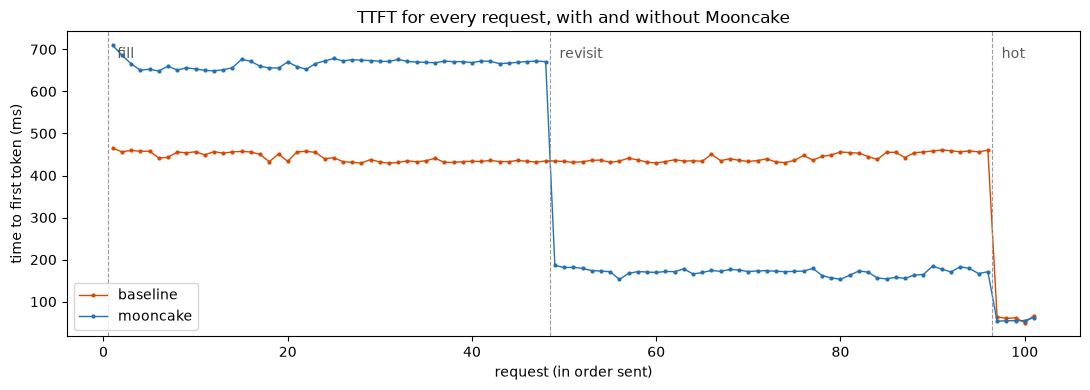

In [3]:
if experiments:
    fig, ax = plt.subplots(figsize=(11, 4))
    for label, color in (("baseline", "#d94801"), ("mooncake", "#2171b5")):
        if label in experiments:
            rows = experiments[label]["metrics"]["requests"]
            ax.plot(range(1, len(rows) + 1), [r["client"]["ttft_s"] * 1000 for r in rows], ".-", color=color, label=label, lw=1, ms=4)
    n = experiments[next(iter(experiments))]["load"]["docs"]
    for x, name in ((0, "fill"), (n, "revisit"), (2 * n, "hot")):
        ax.axvline(x + 0.5, color="#999", lw=0.8, ls="--")
        ax.text(x + 1.5, ax.get_ylim()[1] * 0.95, name, va="top", color="#555")
    ax.set_xlabel("request (in order sent)")
    ax.set_ylabel("time to first token (ms)")
    ax.set_title("TTFT for every request, with and without Mooncake")
    ax.legend()
    plt.tight_layout()
    plt.show()

## What Mooncake moved

`save_put` writes KV into the store after it's computed; `load_get` reads it back into the GPU on a cache miss. Bandwidth = bytes ÷ time spent in the operation.

In [4]:
if "mooncake" in experiments:
    print(f"{'round':<9}{'operation':<13}{'calls':>7}{'GiB':>9}{'time':>10}{'GiB/s':>8}")
    for rnd, s in experiments["mooncake"]["metrics"]["summary"].items():
        for op, m in s["mooncake"].items():
            if m["calls"]:
                gib = m["bytes"] / 2**30
                rate = gib / m["time_s"] if m["time_s"] else float("nan")
                print(f"{rnd:<9}{op:<13}{m['calls']:>7.0f}{gib:>9.2f}{m['time_s']:>8.2f} s{rate:>8.1f}")
else:
    print("No Mooncake run yet.")

round    operation      calls      GiB      time   GiB/s
fill     save_put         144    15.18   25.65 s     0.6
fill     save_exists      144     0.00    0.13 s     0.0
revisit  save_exists       48     0.00    0.11 s     0.0
revisit  load_get          48    15.18    4.65 s     3.3
hot      save_exists        5     0.00    0.00 s     0.0


## Inside one request: where the time goes in each round

vLLM's **queue** time includes waiting for KV to arrive from Mooncake: a request whose prefix was found in the store is held until the load completes, then scheduled. So on a Mooncake revisit, "queue" is mostly the load.

In [5]:
if experiments:
    print(f"{'':<10}{'round':<9}{'TTFT':>9}{'queue':>9}{'prefill':>10}{'other':>9}   (medians, ms)")
    for label in ("baseline", "mooncake"):
        if label not in experiments:
            continue
        rows = experiments[label]["metrics"]["requests"]
        for rnd in ("fill", "revisit", "hot"):
            rr = [r for r in rows if r["round"] == rnd]
            med = lambda f: summarize([f(r) for r in rr])["p50"] * 1000
            ttft, queue, prefill = med(lambda r: r["client"]["ttft_s"]), med(lambda r: r["engine"]["queue_s"]), med(lambda r: r["engine"]["prefill_s"])
            print(f"{label:<10}{rnd:<9}{ttft:>9.0f}{queue:>9.0f}{prefill:>10.0f}{ttft - queue - prefill:>9.0f}")
        print()

          round         TTFT    queue   prefill    other   (medians, ms)
baseline  fill           438        0       410       28
baseline  revisit        437        0       411       27
baseline  hot             61        0        23       39

mooncake  fill           669        0       629       40
mooncake  revisit        171      109        22       41
mooncake  hot             55        0        28       27



## When does Mooncake pay off?

Writing every new prompt's KV to the store makes a document's **first** visit slower; loading it back makes every **evicted revisit** faster.

In [6]:
if len(experiments) == 2:
    s = {l: experiments[l]["metrics"]["summary"] for l in ("baseline", "mooncake")}
    extra_first = (s["mooncake"]["fill"]["ttft_s"]["p50"] - s["baseline"]["fill"]["ttft_s"]["p50"]) * 1000
    saved_revisit = (s["baseline"]["revisit"]["ttft_s"]["p50"] - s["mooncake"]["revisit"]["ttft_s"]["p50"]) * 1000
    print(f"extra TTFT on a first visit:     +{extra_first:.0f} ms")
    print(f"saved TTFT per evicted revisit:  -{saved_revisit:.0f} ms")
    print(f"break-even after {extra_first / saved_revisit:.2f} revisits per document")
    for k in (0, 1, 2, 5):
        print(f"  a document seen {k + 1} time(s): net {'+' if extra_first - k * saved_revisit > 0 else ''}{extra_first - k * saved_revisit:.0f} ms total TTFT with Mooncake")

extra TTFT on a first visit:     +231 ms
saved TTFT per evicted revisit:  -266 ms
break-even after 0.87 revisits per document
  a document seen 1 time(s): net +231 ms total TTFT with Mooncake
  a document seen 2 time(s): net -35 ms total TTFT with Mooncake
  a document seen 3 time(s): net -301 ms total TTFT with Mooncake
  a document seen 6 time(s): net -1099 ms total TTFT with Mooncake


## Does Mooncake cost anything when the cache is big enough?

The Phase 1 single-request trace, rerun with and without Mooncake on the same machine. Here every prompt fits in the GPU cache, so Mooncake can only add overhead (writing every new block to the store).

In [7]:
if traces:
    labels = [l for l in ("baseline", "mooncake") if l in traces]
    prompt_ids = list(traces[labels[0]]["metrics"]["summary"])
    print(f"{'':<14}" + "".join(f"{l + ' TTFT':>16}{l + ' e2e':>16}" for l in labels))
    for p in prompt_ids:
        row = "".join(f"{traces[l]['metrics']['summary'][p]['ttft_s']['p50'] * 1000:>13.1f} ms"
                      f"{traces[l]['metrics']['summary'][p]['e2e_s']['p50'] * 1000:>13.0f} ms" for l in labels)
        print(f"{p:<14}{row}")
else:
    print("No trace runs yet.")

                 baseline TTFT    baseline e2e   mooncake TTFT    mooncake e2e
short_qa_05            29.3 ms          637 ms         31.8 ms          638 ms
summarize_01           32.3 ms         1684 ms         37.6 ms         1687 ms
long_gen_02            28.9 ms         7438 ms         32.4 ms         7434 ms


## Grafana

Both runs on one timeline: baseline around 22:35 to 22:38, then vLLM restarts with Mooncake, and the Mooncake run around 22:41 to 22:44.

![KV cache tiers](images/02_kv_cache_mooncake/grafana_1_kv_cache_tiers.png)

![Engine capacity](images/02_kv_cache_mooncake/grafana_2_engine_capacity.png)

![Latency](images/02_kv_cache_mooncake/grafana_3_latency.png)

![GPU](images/02_kv_cache_mooncake/grafana_4_gpu.png)

![Traffic](images/02_kv_cache_mooncake/grafana_5_traffic.png)

Things to read from them:

* **Where prompt tokens come from**: in the baseline, every prompt token is computed. In the Mooncake run, the revisit round switches to Mooncake (the stacked panel draws each series on top of the one below it, so the Mooncake band sits above the small GPU band from the hot round).
* **Mooncake operation time (p95)**: writes (`save_put`) about 285 ms, reads (`load_get`) about 180 ms. **Failed keys: zero.**
* **The KV cache usage panel stays around 2 to 3%, and that's correct.** vLLM's gauge counts only blocks held by *running* requests: one ~6k token request is 2.8% of 209k tokens. Finished prompts stay in the cache as free, reusable blocks that the gauge doesn't count, and those are what get evicted. The hit ratios measured per request are what show eviction, not this panel.
* **The GPU memory dip around 22:39** is vLLM restarting with the Mooncake config. **The 502s** are the readiness check polling `/v1/models` while vLLM loaded, once per start.
* Dashboard rates are averaged over 1 minute of wall clock time, so the transfer rate panel (~250 to 300 MB/s) is lower than the speed of each individual transfer measured in the results (0.6 GiB/s writing, 3.3 GiB/s reading).

## What happened

**1. Without an extra tier, a working set bigger than the GPU cache gets no reuse at all.** 48 documents × 5,949 tokens is 286k tokens against 209k of GPU cache. Sent in order, each document is evicted before it comes back, so the revisit round was recomputed from scratch: **438 ms → 438 ms TTFT, 0% cache hits**. Only the last 5 documents, still on the GPU, came back fast (61 ms).

**2. With Mooncake, every evicted document came back from CPU memory: 99.5% of each prompt, on all 48.** Revisit TTFT fell from **438 ms to 172 ms (2.6× faster)**. Each document's KV is 339 MB, and it loaded in ~97 ms (3.3 GiB/s) instead of 410 ms of recomputation. vLLM counts that load as queue time, which is why queue jumps to ~109 ms on revisits.

**3. The price is paid on the first visit.** Writing 339 MB per document to the store over TCP ran at only 0.6 GiB/s, and part of that write sits on the critical path: first visit TTFT rose from **438 ms to 670 ms (+53%)**.

**4. Break-even is about one revisit.** +231 ms the first time, −266 ms on every evicted revisit. Workloads where long prompts come back (multi-turn chats, agents resending history, shared documents) win; workloads of one-off prompts only pay.

**5. When prompts fit on the GPU, Mooncake is nearly free.** The single-request trace moved by 2 to 5 ms of TTFT and nothing in end to end latency.

**6. The host CPU shows up in latency.** This run used the Phase 0 machine (server EPYC CPU). Compared with Phase 1's desktop Ryzen machine, decode is identical (~9.6 ms per token), but CPU-bound work is slower: time outside the engine ~7.5 ms vs ~2.7 ms, and cached prefill ~18 ms vs ~12 ms. Fast single-core CPU performance matters for TTFT.

**What would make Mooncake better:** the write path is the weak point. RDMA instead of TCP (not available on these rented machines), or writing asynchronously off the critical path, would shrink the first visit cost. Phase 6 brings the case Mooncake was designed for: several vLLM instances sharing one store, so a prompt computed by one GPU can be reused by another.

## Phase 2 exit criteria

- [x] Mooncake store wired into vLLM through `MooncakeStoreConnector`, as one config change (`vllm/configs/mooncake_store.yaml`)
- [x] Experiment with a working set bigger than the GPU KV cache, measured per request
- [x] Dashboard row for KV cache tiers and Mooncake transfers
- [x] Phase 2 session on the RTX 5090: baseline and Mooncake runs on the same machine
- [x] With and without comparison explained: what Mooncake buys and what it costs